In [14]:
from google.colab import files
uploaded = files.upload()

Saving Assignment_2_QSAR_curated_data.csv to Assignment_2_QSAR_curated_data (1).csv


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Assignment_2_QSAR_curated_data.csv')

df = df[df['class'] != 'intermediate']

def pIC50(input_val):
  molar = input_val * (10**-9)
  return -np.log10(molar)

df['pIC50'] = df['standard_value'].apply(pIC50)
df.head()

,molecule_chembl_id,canonical_smiles,standard_value,class,pIC50
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0,active,6.522879
2,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,400.0,active,6.397940
4,CHEMBL67057,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,100.0,active,7.000000
7,CHEMBL69629,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncn...,100.0,active,7.000000
9,CHEMBL66570,CCN1CCN(C(=O)c2cc(C)c(/C=C3\C(=O)Nc4ncnc(Nc5cc...,100.0,active,7.000000


Task 1

In [16]:
print(df['pIC50'].describe())

count    3713.000000
mean        6.836025
std         1.224683
min         2.795880
25%         6.148742
50%         7.026872
75%         7.696804
max        10.221849
Name: pIC50, dtype: float64


In [17]:
!pip install rdkit

In [19]:
df_eda = df.copy()

Task 2

In [20]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd

def calculate_morgan_fp(smiles):
  mol = Chem.MolFromSmiles(smiles)
  if mol:
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return list(fp)
  return [None] * 2048

print("Generating barcodes for 3,713 molecules...please wait")
fp_list = df_eda['canonical_smiles'].apply(calculate_morgan_fp)

df_fp = pd.DataFrame(fp_list.tolist(), columns=[f'Bit_{i}' for i in range(2048)])

df_final_ml = pd.concat([df_eda[['molecule_chembl_id', 'pIC50']], df_fp], axis=1)

df_final_ml.to_csv('ERBB2_Morgan_Fingerprints.csv', index=False)
print("SUCCESS! 'ERBB2_Morgan_Fingerprints.csv' is ready for download.")

Generating barcodes for 3,713 molecules...please wait
SUCCESS! 'ERBB2_Morgan_Fingerprints.csv' is ready for download.


In [23]:
from rdkit.Chem import Descriptors, Lipinski

def calculate_lipinski(smiles):
  mol = Chem.MolFromSmiles(smiles)
  if mol:
    return pd.Series([Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                      Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol)])
  return pd.Series([None, None, None, None, None])

print("Calculating Lipinski descriptors... please wait.")
df_eda[['MW', 'LogP', 'HBD', 'HBA']] = df_eda['canonical_smiles'].apply(calculate_lipinski)

print("\n--- Statistical Significance Results ---")
from scipy.stats import mannwhitneyu

def check_significance(descriptor):
  active = df_eda[df_eda['class'] == 'active'][descriptor].dropna()
  inactive = df_eda[df_eda['class'] == 'inactive'][descriptor].dropna()

  stat, p = mannwhitneyu(active, inactive)
  status = "SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT"
  print(f'{descriptor}: p-value = {p:.5e} ({status})')

for d in ['MW', 'LogP', 'HBD', 'HBA']:
  check_significance(d)


Calculating Lipinski descriptors... please wait.

--- Statistical Significance Results ---
MW: p-value = 1.70352e-106 (SIGNIFICANT)
LogP: p-value = 1.54947e-25 (SIGNIFICANT)
HBD: p-value = 2.27646e-20 (SIGNIFICANT)
HBA: p-value = 5.06084e-106 (SIGNIFICANT)


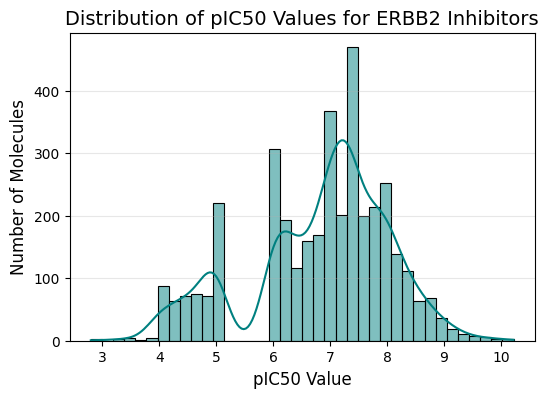

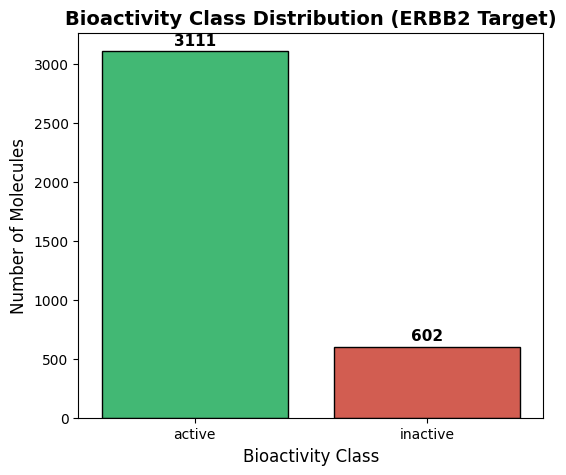

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.histplot(df_eda['pIC50'], kde=True, color='teal')
plt.title('Distribution of pIC50 Values for ERBB2 Inhibitors', fontsize=14)
plt.xlabel('pIC50 Value', fontsize=12)
plt.ylabel('Number of Molecules', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('pIC50_histogram.png', dpi=300)
plt.show

plt.figure(figsize=(6, 5))
sns.countplot(x='class', data=df_eda, hue='class',
              palette={'active': '#2ecc71', 'inactive': '#e74c3c'},
              edgecolor='black')
plt.title('Bioactivity Class Distribution (ERBB2 Target)',
          fontsize=14, fontweight='bold')
plt.xlabel('Bioactivity Class', fontsize=12)
plt.ylabel('Number of Molecules', fontsize=12)

for i, count in enumerate (df_eda['class'].value_counts()):
  plt.text(i, count + 50, str(count), ha='center',
           fontsize=11, fontweight='bold')

plt.savefig('bioactivity_class_plot.png', dpi=300)
plt.show()